In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import BatchNormalization, Dropout
import numpy as np
import tensorflow as tf

In [13]:
#---------------------------------------
# 1. Definition of model (CNN Structure)
#---------------------------------------
classifier = Sequential()

# first Conv Layer
classifier.add(Conv2D(16,(3,3), input_shape= (28,28,1), activation = 'relu'))
classifier.add(BatchNormalization())
classifier.add(MaxPooling2D(pool_size = (2,2)))

# Second Conv Layer
classifier.add(Conv2D(32,(3,3), activation = 'relu'))
classifier.add(BatchNormalization())
classifier.add(MaxPooling2D(pool_size = (2,2)))

classifier.add(Dropout(0.5))

# Fully Connected Layer
classifier.add(Flatten())
classifier.add(Dense(64,activation = 'relu'))

# Output layer (classification of 0~9 numbers)
classifier.add(tf.keras.layers.Dense(10,activation = 'softmax'))

#---------------------------------------
# 2. Compile
#---------------------------------------
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

#---------------------------------------
# 3. Data Loading and Preprocessing (Numpy)
#---------------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and Normalization (0~255 -> 0~1)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

'''
#---------------------------------------
# [Alternative] Data Loading and Preprocessing (JPG)
#---------------------------------------
# This method is used when Minist is stored in JPG image format
# Now performing faster and more accurate learning with the built-in tensorflow mnist dataset

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip = True, vertical_flip = False)

training_set = train_datagen.flow_from_directory('YOUR_DATA_PATH/traing', # Local path(requires user setup)
                                                 target_size = (28,28),
                                                 batch_size = 32,
                                                 color_mode = 'grayscale',
                                                 class_mode = 'categorical')

test_set = train_datagen.flow_from_directory('YOUR_DATA_PATH/testing', # Local path(requires user setup)
                                                 target_size = (28,28),
                                                 batch_size = 32,
                                                 color_mode = 'grayscale',
                                                 class_mode = 'categorical')
classifier.fit(training_set, steps_per_epoch = 10, epochs = 100, validation_data = test_set, validation_steps = 10)
'''
#---------------------------------------
# 4. Machine Learning
#---------------------------------------
history = classifier.fit(x_train, y_train, epochs = 10, batch_size=32, validation_data=(x_test, y_test))

#---------------------------------------
# 5. Saving Model
#---------------------------------------
classifier.save('/content/drive/MyDrive/Colab Notebooks/MNIST/cnn_numbers.keras') # Save to relative path (important)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 30ms/step - accuracy: 0.9312 - loss: 0.2174 - val_accuracy: 0.9818 - val_loss: 0.0563
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9744 - loss: 0.0821 - val_accuracy: 0.9878 - val_loss: 0.0347
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9791 - loss: 0.0678 - val_accuracy: 0.9881 - val_loss: 0.0342
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9825 - loss: 0.0567 - val_accuracy: 0.9900 - val_loss: 0.0305
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9853 - loss: 0.0477 - val_accuracy: 0.9899 - val_loss: 0.0275
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9863 - loss: 0.0447 - val_accuracy: 0.9893 - val_loss: 0.0328
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.9868 - loss: 0.0409 - val_accuracy: 0.9816 - val_loss: 0.0599
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9884 -

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [15]:
def plot_history(history):

  # Summarize history of accuracy
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train','test'], loc = 'upper left')
  plt.show()

  # Summarize history for loss
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train','test'], loc = 'upper left')
  plt.show()

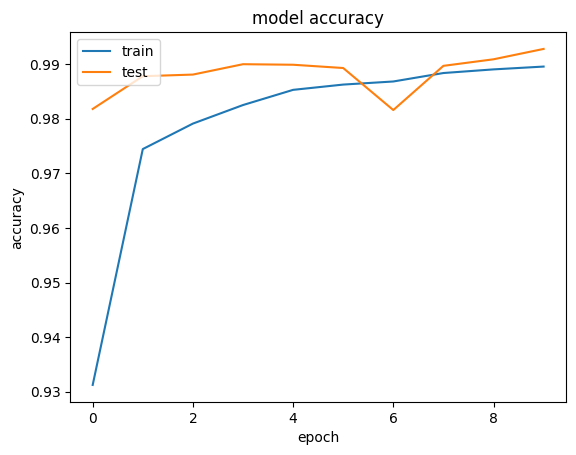

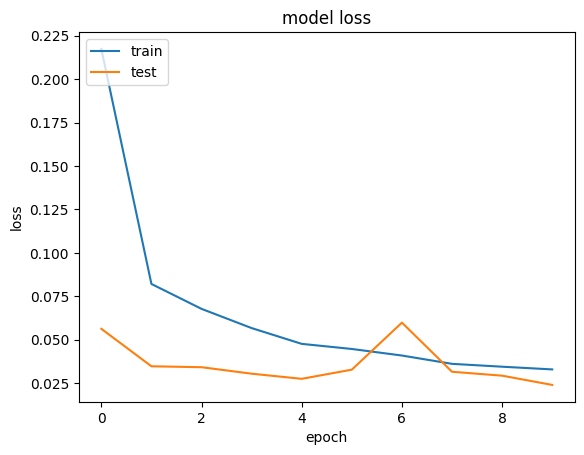

In [16]:
plot_history(history)